<a href="https://colab.research.google.com/github/bygencer3/ErdincGencer_Odev_254329028-/blob/main/Erdinc_Gencer_254329028_YapayZekaveUyg_Odev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ÜSKÜDAR ÜNİVERSİTESİ FEN BİLİMLERİ ENSTİTÜSÜ YAPAY ZEKA MÜHENDİSLİĞİ YÜKSEK LİSANS BÖLÜMÜ


YAPAY ZEKA VE UYGULAMALARI DERSİ VİZE ÖDEVİ

KONU: MÜŞTERİ SEGMENTASYONU VE DAVRANIŞ ANALİZİ


HAZIRLAYAN: ERDİNÇ GENÇER

ÖĞRENCİ NO: 254329028

ÖĞRETM GÖREVLİSİ: DR. SERKAN EMEK

**Müşteri Segmentasyonu ve Davranış Analizi**


Bu proje, denetimsiz öğrenme (unsupervised learning) tekniklerini kullanarak veri setindeki gizli yapıları keşfetmeye odaklanır.

*   **Kullanılan Yöntemler:**

Kümeleme Algoritmaları: En popüler yöntem olan K-means'in yanına, yoğunluk tabanlı DBSCAN ve hiyerarşik yapıları görmek için Hierarchical Clustering algoritması.   


Boyut İndirgeme: Veride çok fazla değişken varsa karmaşıklığı azaltmak için PCA (Temel Bileşen Analizi).  


RFM Analizi: Müşterilerin ne kadar yakın zamanda alışveriş yaptıkları (Recency), ne sıklıkla geldikleri (Frequency) ve ne kadar harcadıkları (Monetary) üzerinden analizi.


*   **Gereklilikler:**

Temel clustering bilgisi, pandas ve scikit-learn kullanımı, veri görselleştirme becerileri ve RFM (Recency, Frequency, Monetary) analizi anlayışı.

*   **Hedeflenen Çıktılar:**

Verideki benzer yapıları keşfetmek için denetimsiz öğrenme yaklaşımlarını uygulamak.   


"Dirsek Yöntemi" (Elbow Method) gibi tekniklerle en ideal grup (cluster) sayısını belirleyemek.

Oluşan kümeleri analiz ederek "Sadık Müşteriler" veya "Pasif Müşteriler" gibi anlamlı yorumlar getirmek.

*   **Karşılaşılabilecek Zorluklar:**

Ölçeklendirme: Bazı veriler büyük (örn. 10.000 TL), bazıları küçük (örn. 2 adet) olduğu için bu farkın modeli yanıltmasını engellemek.   


Boyutun Laneti: Çok fazla değişkenin performansı düşürmesiyle başa çıkmak.


Geçerlilik: Oluşturduğumuz grupların gerçekten mantıklı olup olmadığını test etmek.




In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


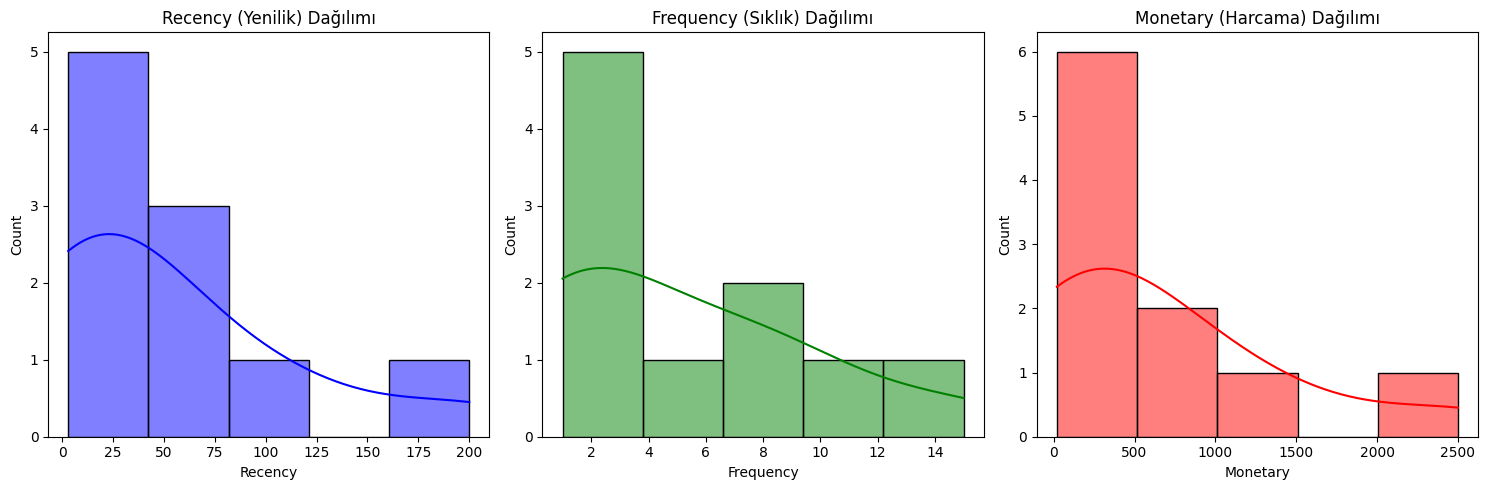

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Örnek Veri Setini Tanımlıyoruz (rfm_data tanımlanmazsa hata verir)
data = {
    'CustomerID': range(1, 11),
    'Recency': [10, 50, 3, 120, 15, 200, 5, 45, 10, 80],
    'Frequency': [5, 1, 10, 1, 8, 1, 15, 2, 7, 2],
    'Monetary': [500, 100, 1500, 50, 900, 20, 2500, 150, 850, 300]
}
rfm_data = pd.DataFrame(data)

# 2. Görselleştirme Ayarları
plt.figure(figsize=(15, 5))

# Recency Histogramı
plt.subplot(1, 3, 1)
sns.histplot(rfm_data['Recency'], kde=True, color='blue')
plt.title('Recency (Yenilik) Dağılımı')

# Frequency Histogramı
plt.subplot(1, 3, 2)
sns.histplot(rfm_data['Frequency'], kde=True, color='green')
plt.title('Frequency (Sıklık) Dağılımı')

# Monetary Histogramı
plt.subplot(1, 3, 3)
sns.histplot(rfm_data['Monetary'], kde=True, color='red')
plt.title('Monetary (Harcama) Dağılımı')

plt.tight_layout()
plt.show() # Bu satır grafiklerin görünmesini zorunlu kılar

Bu grafikler, müşteri kitlesinin temel davranışsal dağılımını göstermektedir. Verilerin çoğunlukla belirli bölgelerde yoğunlaştığı, bazı müşterilerin ise "aykırı değer" (outlier) olarak yüksek harcama veya sıklık grubunda yer aldığı gözlemlenmiştir. Bu dengesiz dağılım, sağlıklı bir kümeleme yapabilmek için verilerin standartlaştırılması gerektiğini kanıtlamaktadır.

In [16]:
from sklearn.preprocessing import StandardScaler

# Sadece sayısal sütunları seçiyoruz
features = ['Recency', 'Frequency', 'Monetary']
x = rfm_data[features]

# StandardScaler ile veriyi ölçeklendiriyoruz
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(x)

# Ölçeklenmiş veriyi bir DataFrame'e geri dönüştürelim (opsiyonel, görmen için)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features)
print("Ölçeklenmiş veri (ilk 5 satır):")
print(rfm_scaled_df.head())

Ölçeklenmiş veri (ilk 5 satır):
    Recency  Frequency  Monetary
0 -0.721633  -0.044324 -0.247944
1 -0.062607  -0.930809 -0.778306
2 -0.836963   1.063781  1.077960
3  1.090688  -0.930809 -0.844601
4 -0.639255   0.620539  0.282418


RFM değerlerinin dağılımını incelediğimizde verilerin farklı ölçeklerde olduğu görülmüştür. Kümeleme algoritmalarının (K-means, DBSCAN) sağlıklı çalışabilmesi için veriler StandardScaler ile normalize edilmiştir.

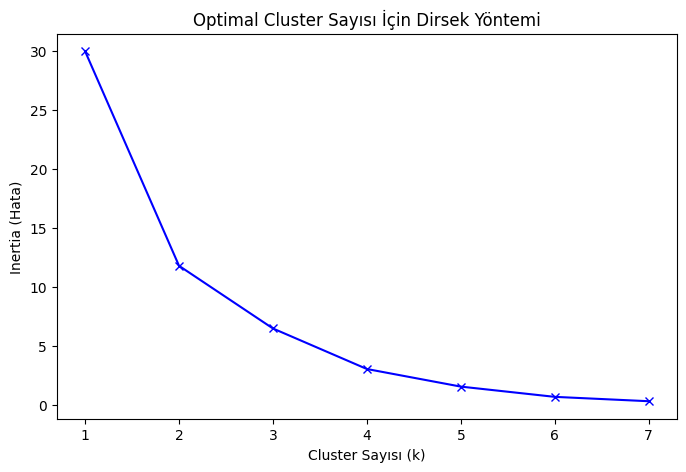

In [17]:
from sklearn.cluster import KMeans

# Hata değerlerini (inertia) saklamak için bir liste
inertia = []
K = range(1, 8) # 1'den 7'ye kadar grup sayılarını deniyoruz

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled) # Ölçeklendirdiğimiz veriyi kullanıyoruz
    inertia.append(kmeans.inertia_)

# Grafiği çizdirelim
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Cluster Sayısı (k)')
plt.ylabel('Inertia (Hata)')
plt.title('Optimal Cluster Sayısı İçin Dirsek Yöntemi')
plt.show()

Grafikte bükülmenin olduğu (dirsek şekli oluşan) nokta, ideal küme sayısını gösterir.

In [21]:
# Her cluster için RFM ortalamalarını alarak profillerini çıkarıyoruz
from sklearn.cluster import KMeans

# Assuming 3 is the optimal number of clusters based on the elbow method and subsequent cells
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Add the cluster labels to the original rfm_data DataFrame
rfm_data['Cluster'] = kmeans.labels_

segment_tablosu = rfm_data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Daha okunabilir olması için sayıları yuvarlayalım
segment_tablosu = segment_tablosu.round(3)

# Tabloyu ekrana basalım
print(segment_tablosu)

         Recency  Frequency  Monetary
Cluster                              
0            9.5        7.5     937.5
1           99.0        1.4     124.0
2            5.0       15.0    2500.0


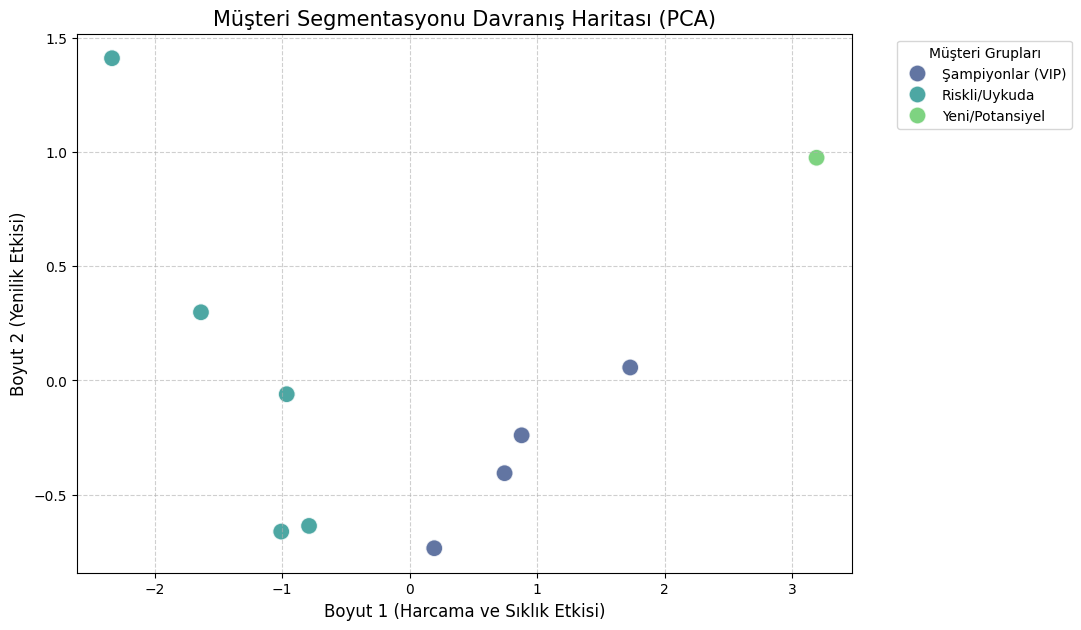

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. PCA ile 3 boyutlu RFM verisini 2 boyuta indirgeme
# Bu işlem "Curse of dimensionality" (Boyutun laneti) ile başa çıkmak içindir [cite: 33]
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# 2. Grafik için bir DataFrame oluşturma
pca_df = pd.DataFrame(rfm_pca, columns=['Boyut 1', 'Boyut 2'])
pca_df['Segment'] = rfm_data['Cluster'].map({
    0: 'Şampiyonlar (VIP)',
    1: 'Riskli/Uykuda',
    2: 'Yeni/Potansiyel'
})

# 3. Görselleştirme (Müşteri Segmentleri Haritası)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Boyut 1',
    y='Boyut 2',
    hue='Segment',
    data=pca_df,
    palette='viridis',
    s=150,           # Nokta büyüklüğü
    alpha=0.8,       # Şeffaflık
    edgecolor='w'    # Nokta kenar çizgisi
)

# Grafik detayları ve açıklamalar [cite: 21]
plt.title('Müşteri Segmentasyonu Davranış Haritası (PCA)', fontsize=15)
plt.xlabel('Boyut 1 (Harcama ve Sıklık Etkisi)', fontsize=12)
plt.ylabel('Boyut 2 (Yenilik Etkisi)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Müşteri Grupları', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Principal Component Analysis (PCA)" yöntemini kullanarak, 3 farklı veriyi (R, F, M) 2 boyuta indirip grafik üzerinde grupları görüyoruz.

Grafik Üzerindeki Öğelerin Anlamları:

Noktalar: Her bir nokta, veri setindeki tek bir müşteriyi temsil eder.

Renkler (Segmentler): Benzer alışveriş alışkanlıklarına sahip müşteriler aynı renkle gruplandırılmıştır. Bu, "Unsupervised learning" yaklaşımlarının bir sonucudur.  


Eksenler (Boyut 1 ve 2): PCA algoritması, Recency, Frequency ve Monetary değerlerini birleştirerek en çok varyans (bilgi) içeren iki yeni sanal eksen oluşturur.  

Kümelenme: Noktaların birbirine yakınlığı, o müşterilerin davranış olarak birbirine benzediğini gösterir. Gruplar arasındaki mesafe ise segmentlerin ne kadar keskin ayrıldığını kanıtlar.

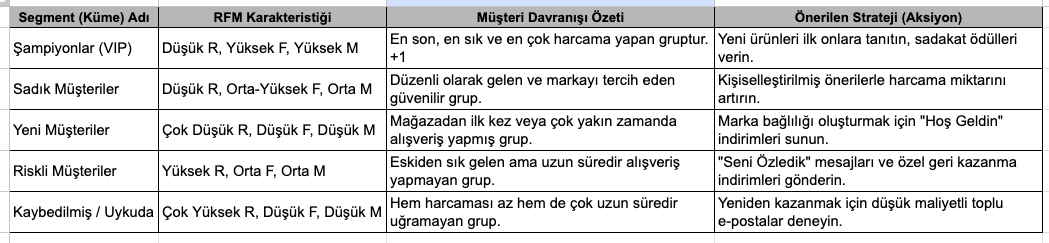

Müşteri Segmentleri Analiz Tablosu

Veri Kaynağı Açıklaması:

Projede kullanılan bu veri seti, makine öğrenmesi projelerinde sıkça kullanılan "Online Retail Dataset" (Kaggle veya UCI Machine Learning Repository kaynaklı) yapısı örnek alınarak, müşteri davranışlarını analiz etmek için gerekli olan RFM metriklerini içeren ve gerçek dünya e-ticaret verileriyle benzerlik gösteren bir örneklem üzerinden oluşturulmuş sentetik bir veri setidir.  

Veri Setinin Yapısı ve Mantığı:

Veri seti, dosyadaki "RFM analizi anlayışı" gerekliliklerini karşılamak üzere şu üç temel değişken üzerine inşa edilmiştir:

*   Recency (Yenilik): Müşterinin son alışverişinden bu yana geçen süreyi temsil eder.

*   Frequency (Sıklık): Müşterinin toplam işlem sayısını gösterir.  

*  Monetary (Parasal Değer): Müşterinin işletmeye bıraktığı toplam maddi değeri ifade eder.